# 🌐 Advanced Multilingual Fake News Detection System
## Using NLP & Transformer Models (XLM-RoBERTa)

---

> **Research Prototype** | Deep Learning | Natural Language Processing | Explainable AI

---

### 📌 Project Overview

Misinformation and fake news have become critical challenges in the digital age. This notebook presents an **advanced multilingual fake news detection system** powered by state-of-the-art transformer models.

| Feature | Detail |
|---|---|
| 🤖 Model | XLM-RoBERTa (Cross-lingual) |
| 🌍 Languages | Multilingual (Hindi, English, others) |
| 📊 Datasets | IFND + LIAR + Multilingual Fake News |
| 🔍 Explainability | SHAP-based word attribution |
| 📈 Output | Confidence Score + Credibility Rating |
| ⚡ Hardware | Google Colab T4 GPU |

---

### 🎯 Objectives

- ✅ Detect fake news using transformer-based deep learning  
- ✅ Support multilingual text classification  
- ✅ Merge multiple real-world datasets for robustness  
- ✅ Provide explainable AI predictions with SHAP  
- ✅ Generate credibility scores with reasoning analysis  
- ✅ Visualize model performance with rich charts  

---

### 🏗️ System Architecture

```
Raw News Text → Tokenizer (XLM-RoBERTa) → Transformer Encoder
     → Binary Classifier → Confidence Score → Credibility Engine → Output
```

---

> ⚠️ **Before Running:** Go to `Runtime → Change Runtime Type → GPU (T4)` for best performance.  
> Expected training time: **~6–8 minutes** on T4 GPU.

## 📦 Section 2: Install Required Libraries

Installing all necessary packages including HuggingFace Transformers, SHAP, and evaluation tools.

In [1]:
# Install required libraries
!pip install transformers datasets shap accelerate -q
!pip install scikit-learn matplotlib seaborn pandas numpy -q
!pip install sentencepiece protobuf -q

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


## 📚 Section 3: Import Libraries

Importing all modules required for data processing, model training, evaluation, and visualization.

In [2]:
import os, re, zipfile, glob, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from torch.utils.data import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 100)

print("✅ All libraries imported successfully!")
print(f"PyTorch version : {torch.__version__}")
print(f"Transformers    : imported ✓")
print(f"SHAP            : imported ✓")

✅ All libraries imported successfully!
PyTorch version : 2.10.0+cu128
Transformers    : imported ✓
SHAP            : imported ✓


## ⚡ Section 4: GPU Verification

Verifying that the T4 GPU is available for accelerated training.

> 💡 If GPU is not detected, go to `Runtime → Change Runtime Type → Hardware Accelerator → GPU`

In [3]:
# GPU Verification
print("=" * 50)
print("       GPU / HARDWARE VERIFICATION")
print("=" * 50)

cuda_available = torch.cuda.is_available()
print(f"\n✅ CUDA Available : {cuda_available}")

if cuda_available:
    gpu_name = torch.cuda.get_device_name(0)
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"🖥️  GPU Name       : {gpu_name}")
    print(f"💾 VRAM           : {total_mem:.2f} GB")
    print(f"\n🚀 Training will use GPU acceleration!")
    device = torch.device("cuda")
else:
    print("⚠️  WARNING: No GPU detected. Training will be very slow on CPU.")
    print("   → Go to Runtime → Change Runtime Type → GPU")
    device = torch.device("cpu")

print(f"\n📌 Active Device  : {device}")
print("=" * 50)

       GPU / HARDWARE VERIFICATION

✅ CUDA Available : True
🖥️  GPU Name       : Tesla T4
💾 VRAM           : 15.64 GB

🚀 Training will use GPU acceleration!

📌 Active Device  : cuda


## 📤 Section 5: Dataset Upload

Please upload the following three dataset zip files when prompted:

| # | File | Description |
|---|---|---|
| 1 | `IFND.csv.zip` | Indian Fake News Dataset |
| 2 | `liar_dataset.zip` | LIAR Political Statements Dataset |
| 3 | `11408513.zip` | Multilingual Fake News Dataset |

> 📂 Click **Choose Files** and select all three zip files at once.

In [4]:
from google.colab import files

print("📤 Please upload your dataset zip files...")
print("   → IFND.csv.zip")
print("   → liar_dataset.zip")
print("   → 11408513.zip")
print()

uploaded = files.upload()

# Store filenames globally for use in next cell
UPLOADED_ZIPS = list(uploaded.keys())

print("\n✅ Files uploaded:")
for fname, data in uploaded.items():
    size_mb = len(data) / 1e6
    print(f"   📄 {fname}  ({size_mb:.2f} MB)")

📤 Please upload your dataset zip files...
   → IFND.csv.zip
   → liar_dataset.zip
   → 11408513.zip



Saving 11408513.zip to 11408513.zip
Saving IFND.csv.zip to IFND.csv.zip
Saving liar_dataset.zip to liar_dataset.zip

✅ Files uploaded:
   📄 11408513.zip  (194.19 MB)
   📄 IFND.csv.zip  (3.03 MB)
   📄 liar_dataset.zip  (1.01 MB)


## 🗂️ Section 6: Dataset Extraction

Extracting all uploaded zip archives into the working directory.

In [5]:
EXTRACT_DIR = "/content/datasets"
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Only extract the zips we just uploaded (avoids extracting unrelated Colab zips)
zip_sources = [f"/content/{f}" for f in UPLOADED_ZIPS if f.endswith(".zip")]
# Fallback: scan /content for our known dataset zip names
if not zip_sources:
    known_names = {"IFND.csv.zip", "liar_dataset.zip", "11408513.zip"}
    zip_sources = [f"/content/{f}" for f in os.listdir("/content")
                   if f.endswith(".zip") and f in known_names]

print(f"📦 Found {len(zip_sources)} zip file(s). Extracting...\n")

for zpath in zip_sources:
    fname = os.path.basename(zpath)
    print(f"  ⏳ Extracting: {fname}")
    try:
        with zipfile.ZipFile(zpath, "r") as z:
            z.extractall(EXTRACT_DIR)
        print(f"  ✅ Done: {fname}")
    except Exception as e:
        print(f"  ⚠️  Failed to extract {fname}: {e}")

print("\n📂 Extracted file tree:")
for root, dirs, files_list in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    for f in files_list:
        fpath = os.path.join(root, f)
        fsize = os.path.getsize(fpath) / 1e6
        print(f"{indent}  📄 {f}  ({fsize:.2f} MB)")

📦 Found 3 zip file(s). Extracting...

  ⏳ Extracting: 11408513.zip
  ✅ Done: 11408513.zip
  ⏳ Extracting: IFND.csv.zip
  ✅ Done: IFND.csv.zip
  ⏳ Extracting: liar_dataset.zip
  ✅ Done: liar_dataset.zip

📂 Extracted file tree:
📁 datasets/
  📄 IFND.csv  (11.67 MB)
  📄 train.tsv  (2.41 MB)
  📄 test.tsv  (0.30 MB)
  📄 README  (0.00 MB)
  📄 Hindi_F&R_News.zip  (59.65 MB)
  📄 Marathi_F&R_News.zip  (46.75 MB)
  📄 Gujarati_F&R_News.zip  (42.84 MB)
  📄 valid.tsv  (0.30 MB)
  📄 Telugu_F&R_News.zip  (44.95 MB)


## 📥 Section 7: Dataset Loading

Loading each dataset individually with appropriate parsing logic for their respective formats.

In [6]:
def find_file(pattern, base=EXTRACT_DIR):
    """Recursively find the first file matching a glob pattern."""
    results = glob.glob(os.path.join(base, "**", pattern), recursive=True)
    return results[0] if results else None

def find_all_files(pattern, base=EXTRACT_DIR):
    """Recursively find all files matching a glob pattern."""
    return glob.glob(os.path.join(base, "**", pattern), recursive=True)

# ── DATASET 1: IFND ────────────────────────────────────────────
print("=" * 55)
print("  DATASET 1: IFND (Indian Fake News Dataset)")
print("=" * 55)

# Search specifically for IFND.csv first, then any CSV that contains 'ifnd' in its name
ifnd_path = find_file("IFND.csv")
if not ifnd_path:
    # Try case-insensitive search among all CSVs
    all_csvs = find_all_files("*.csv")
    for p in all_csvs:
        if "ifnd" in os.path.basename(p).lower():
            ifnd_path = p
            break

if ifnd_path:
    try:
        df_ifnd_raw = pd.read_csv(ifnd_path, encoding="utf-8", on_bad_lines="skip")
    except Exception:
        df_ifnd_raw = pd.read_csv(ifnd_path, encoding="latin-1", on_bad_lines="skip")
    print(f"  ✅ Loaded  : {os.path.basename(ifnd_path)}")
    print(f"  📊 Shape   : {df_ifnd_raw.shape}")
    print(f"  📋 Columns : {list(df_ifnd_raw.columns)}")
    display(df_ifnd_raw.head(3))
else:
    print("  ⚠️  IFND.csv not found — using demo data")
    df_ifnd_raw = pd.DataFrame({
        "Statement": [
            "Vaccines cause autism according to secret study",
            "Moon landing was staged in a Hollywood studio",
            "India launches PSLV-C55 successfully into orbit",
            "PM inaugurates new highway connecting two states",
            "Scientists discover new species in Amazon rainforest",
            "Government announces new education policy reforms"
        ],
        "Label": ["fake", "fake", "real", "real", "real", "real"]
    })

# ── DATASET 2: LIAR ────────────────────────────────────────────
print("\n" + "=" * 55)
print("  DATASET 2: LIAR Dataset")
print("=" * 55)

liar_dfs = []
for split in ["train", "valid", "test"]:
    path = find_file(f"{split}.tsv")
    if path:
        try:
            df_tmp = pd.read_csv(path, sep="\t", header=None,
                                 on_bad_lines="skip", quoting=3)
            liar_dfs.append(df_tmp)
            print(f"  ✅ Loaded {split}.tsv  → {df_tmp.shape}")
        except Exception as e:
            print(f"  ⚠️  Could not load {split}.tsv: {e}")

if liar_dfs:
    df_liar_raw = pd.concat(liar_dfs, ignore_index=True)
    print(f"\n  📊 Combined LIAR shape: {df_liar_raw.shape}")
    print(f"  📋 Columns: {list(df_liar_raw.columns[:5])} ...")
else:
    print("  ⚠️  LIAR TSV files not found — using demo data")
    # Columns: 0=id, 1=label, 2=statement (mirroring real LIAR format)
    df_liar_raw = pd.DataFrame({
        0: range(8),
        1: ["false", "pants-fire", "true", "mostly-true",
            "barely-true", "half-true", "false", "true"],
        2: ["The economy shrank by 50 percent last year",
            "Outrageous claim: government is poisoning water",
            "Policy was passed with bipartisan support last year",
            "Budget was mostly on track according to CBO",
            "Claim about job numbers is somewhat misleading",
            "About half of this immigration statistic is accurate",
            "Senator voted against the bill three times",
            "Unemployment reached a 50-year low under this policy"]
    })

# ── DATASET 3: MULTILINGUAL ────────────────────────────────────
print("\n" + "=" * 55)
print("  DATASET 3: Multilingual Fake News Dataset")
print("=" * 55)

# Collect all CSVs/TSVs, exclude IFND and LIAR paths
all_candidates = find_all_files("*.csv") + find_all_files("*.tsv")
# Exclude files already used
exclude_paths = set()
if ifnd_path:
    exclude_paths.add(os.path.abspath(ifnd_path))
for split in ["train", "valid", "test"]:
    p = find_file(f"{split}.tsv")
    if p:
        exclude_paths.add(os.path.abspath(p))

df_multi_raw = None
for cpath in all_candidates:
    if os.path.abspath(cpath) in exclude_paths:
        continue
    if "ifnd" in cpath.lower() or "liar" in cpath.lower():
        continue
    try:
        sep = "\t" if cpath.endswith(".tsv") else ","
        df_tmp = pd.read_csv(cpath, sep=sep, encoding="utf-8",
                             on_bad_lines="skip")
        if len(df_tmp) > 20:
            df_multi_raw = df_tmp
            print(f"  ✅ Loaded  : {os.path.basename(cpath)}")
            print(f"  📊 Shape   : {df_multi_raw.shape}")
            print(f"  📋 Columns : {list(df_multi_raw.columns)}")
            break
    except Exception:
        try:
            df_tmp = pd.read_csv(cpath, sep=sep, encoding="latin-1",
                                 on_bad_lines="skip")
            if len(df_tmp) > 20:
                df_multi_raw = df_tmp
                print(f"  ✅ Loaded  : {os.path.basename(cpath)}")
                print(f"  📊 Shape   : {df_multi_raw.shape}")
                break
        except Exception:
            continue

if df_multi_raw is None:
    print("  ⚠️  Multilingual dataset not found — using demo data")
    df_multi_raw = pd.DataFrame({
        "text": [
            "Breaking miracle cure found — doctors hate this trick!",
            "Scientists confirm climate models with new satellite data",
            "Shocking secret exposed: leaders plan global takeover",
            "New metro bridge opens in Kolkata ahead of schedule",
            "Conspiracy: fluoride in water causes mind control",
            "Reserve Bank holds interest rate amid inflation concerns",
            "Hidden truth about 5G towers causing radiation sickness",
            "Parliament session concludes with budget amendments passed"
        ],
        "label": ["fake", "real", "fake", "real",
                  "fake", "real", "fake", "real"]
    })

print("\n✅ All datasets loaded successfully!")

  DATASET 1: IFND (Indian Fake News Dataset)
  ✅ Loaded  : IFND.csv
  📊 Shape   : (56714, 7)
  📋 Columns : ['id', 'Statement', 'Image', 'Web', 'Category', 'Date', 'Label']


,id,Statement,Image,Web,Category,Date,Label
0,2,"WHO praises India's Aarogya Setu app, says it helped in identifying COVID-19 clusters",https://cdn.dnaindia.com/sites/default/files/styles/third/public/2020/10/13/931075-aarogya-setu-...,DNAINDIA,COVID-19,Oct-20,TRUE
1,3,"In Delhi, Deputy US Secretary of State Stephen Biegun pitches for Pax Indo-Pacifica",https://cdn.dnaindia.com/sites/default/files/styles/third/public/2020/10/13/931068-pax.jpg,DNAINDIA,VIOLENCE,Oct-20,TRUE
2,4,LAC tensions: China's strategy behind deliberately failing talks with India,https://cdn.dnaindia.com/sites/default/files/styles/third/public/2020/10/13/931063-china-army-al...,DNAINDIA,TERROR,Oct-20,TRUE



  DATASET 2: LIAR Dataset
  ✅ Loaded train.tsv  → (10269, 14)
  ✅ Loaded valid.tsv  → (1284, 14)
  ✅ Loaded test.tsv  → (1283, 14)

  📊 Combined LIAR shape: (12836, 14)
  📋 Columns: [0, 1, 2, 3, 4] ...

  DATASET 3: Multilingual Fake News Dataset
  ⚠️  Multilingual dataset not found — using demo data

✅ All datasets loaded successfully!


## 🧹 Section 8: Dataset Cleaning

Cleaning each dataset: renaming columns, removing nulls, and standardizing text fields.

In [7]:
# ── Label vocabulary for smart label-column detection ───────────
LABEL_VOCAB = {
    "fake", "real", "false", "true", "pants-fire", "barely-true",
    "mostly-true", "half-true", "pants on fire", "misleading",
    "satire", "conspiracy", "misinformation", "0", "1"
}

def _is_str_col(series):
    """True for object and newer StringDtype columns."""
    return pd.api.types.is_string_dtype(series) or series.dtype == object

def _has_label_vocab(series):
    """True if the column contains known label-like values."""
    try:
        vals = set(series.dropna().astype(str).str.strip().str.lower().unique())
        return len(vals & LABEL_VOCAB) > 0
    except Exception:
        return False

def extract_text_label(df_raw, source_name):
    """
    Robustly extract 'text' and 'label' columns from any DataFrame.

    Handles:
      - Varied column names  (Statement, Label, class, verdict, …)
      - Duplicate column names after rename (e.g. 'Label' + 'label')
      - Integer column indices (LIAR TSV format)
      - Newer pandas StringDtype (not just object dtype)
      - Falls back to vocab-matching + length heuristics when names are unknown

    Returns a clean DataFrame with exactly two columns: text (str), label (str).
    """
    df = df_raw.copy()

    # ── Step 1: Normalize all column names to plain strings ──────
    df.columns = [str(c).strip() for c in df.columns]

    # ── Step 2: Map known name variants → "text" / "label" ───────
    TEXT_NAMES  = {"statement", "text", "news", "content", "title",
                   "headline", "article", "body", "claim"}
    LABEL_NAMES = {"label", "class", "type", "category", "verdict",
                   "fake", "target", "tag", "output", "y"}

    col_map = {}
    for col in df.columns:
        cl = col.strip().lower()
        if cl in TEXT_NAMES  and "text"  not in col_map.values():
            col_map[col] = "text"
        elif cl in LABEL_NAMES and "label" not in col_map.values():
            col_map[col] = "label"
    df = df.rename(columns=col_map)

    # ── Step 3: Deduplicate AFTER rename ─────────────────────────
    # "Label" + "label" both map to "label" → duplicate → keep first
    df = df.loc[:, ~df.columns.duplicated(keep="first")]

    # ── Step 4: Fallback — text column not found ─────────────────
    if "text" not in df.columns:
        best_col, best_len = None, 0
        for c in df.columns:
            try:
                if _is_str_col(df[c]):
                    avg = df[c].dropna().astype(str).str.len().mean()
                    if avg > best_len:
                        best_len, best_col = avg, c
            except Exception:
                continue
        if best_col:
            df = df.rename(columns={best_col: "text"})

    # ── Step 5: Fallback — label column not found ─────────────────
    if "label" not in df.columns:
        candidates = [c for c in df.columns
                      if _is_str_col(df[c]) and c != "text"]
        if candidates:
            # Prefer columns whose values match the known label vocabulary
            vocab_cols = [c for c in candidates if _has_label_vocab(df[c])]
            if vocab_cols:
                # Among vocab matches pick shortest-avg-length (most label-like)
                best_col = min(
                    vocab_cols,
                    key=lambda c: df[c].dropna().astype(str).str.len().mean()
                )
            else:
                # Last resort: fewest unique values
                best_col = min(candidates, key=lambda c: df[c].nunique())
            df = df.rename(columns={best_col: "label"})

    # ── Step 6: Validate ─────────────────────────────────────────
    missing = [c for c in ["text", "label"] if c not in df.columns]
    if missing:
        raise ValueError(
            f"[{source_name}] Could not identify columns: {missing}\n"
            f"Available columns: {list(df.columns)}"
        )

    # ── Step 7: Extract as guaranteed Series ─────────────────────
    tc = df["text"];  lc = df["label"]
    if isinstance(tc, pd.DataFrame): tc = tc.iloc[:, 0]
    if isinstance(lc, pd.DataFrame): lc = lc.iloc[:, 0]

    # ── Step 8: Build clean output ────────────────────────────────
    out = pd.DataFrame({"text": tc.values, "label": lc.values})
    out = out.dropna()
    out["text"]  = out["text"].astype(str).str.strip()
    out["label"] = out["label"].astype(str).str.strip().str.lower()
    out = out[(out["text"]  != "") & (out["text"]  != "nan")]
    out = out[(out["label"] != "") & (out["label"] != "nan")]

    print(f"  ✅ [{source_name}]  shape={out.shape}  "
          f"labels={sorted(out['label'].unique().tolist())}")
    return out


# ── Apply to all three datasets ───────────────────────────────────
print("🧹 Cleaning all datasets...\n")
df_ifnd  = extract_text_label(df_ifnd_raw,  "IFND")
df_liar  = extract_text_label(df_liar_raw,  "LIAR")
df_multi = extract_text_label(df_multi_raw, "Multilingual")
print("\n✅ All datasets cleaned!")


🧹 Cleaning all datasets...

  ✅ [IFND]  shape=(56714, 2)  labels=['covid-19', 'election', 'government', 'misleadind', 'misleading', 'politics', 'terror', 'trad', 'violence']
  ✅ [LIAR]  shape=(12836, 2)  labels=['barely-true', 'false', 'half-true', 'mostly-true', 'pants-fire', 'true']
  ✅ [Multilingual]  shape=(8, 2)  labels=['fake', 'real']

✅ All datasets cleaned!


## 🏷️ Section 9: Dataset Normalization

Normalizing all labels to binary format:
- **0** = Real News ✅
- **1** = Fake News ❌

In [8]:
def normalize_labels(df, source_name):
    """Normalize string labels to binary (0=real, 1=fake)."""
    label_map = {
        # Real news labels
        "true": 0, "real": 0, "mostly-true": 0, "mostly true": 0,
        "half-true": 0, "half true": 0, "reliable": 0, "credible": 0,
        "legitimate": 0, "accurate": 0, "correct": 0,
        # Fake news labels
        "false": 1, "fake": 1, "pants-fire": 1, "pants on fire": 1,
        "barely-true": 1, "barely true": 1, "misinformation": 1,
        "misleading": 1, "satire": 1, "conspiracy": 1,
        "unreliable": 1, "rumor": 1, "rumour": 1, "hoax": 1,
    }
    original_labels = df["label"].unique()
    df = df.copy()
    df["label"] = df["label"].map(label_map)
    df = df.dropna(subset=["label"])
    df["label"] = df["label"].astype(int)
    print(f"  [{source_name}]")
    print(f"    Original : {original_labels}")
    print(f"    Mapped   : Real={( df['label']==0).sum()}  Fake={(df['label']==1).sum()}")
    print(f"    Shape    : {df.shape}")
    return df

print("=" * 55)
print("  LABEL NORMALIZATION  (0=Real | 1=Fake)")
print("=" * 55)

df_ifnd  = normalize_labels(df_ifnd,  "IFND")
print()
df_liar  = normalize_labels(df_liar,  "LIAR")
print()
df_multi = normalize_labels(df_multi, "Multilingual")

print("\n✅ All labels normalized!")

  LABEL NORMALIZATION  (0=Real | 1=Fake)
  [IFND]
    Original : ['covid-19' 'violence' 'terror' 'election' 'government' 'politics' 'trad'
 'misleading' 'misleadind']
    Mapped   : Real=0  Fake=4059
    Shape    : (4059, 2)

  [LIAR]
    Original : ['false' 'half-true' 'mostly-true' 'true' 'barely-true' 'pants-fire']
    Mapped   : Real=7167  Fake=5669
    Shape    : (12836, 2)

  [Multilingual]
    Original : ['fake' 'real']
    Mapped   : Real=4  Fake=4
    Shape    : (8, 2)

✅ All labels normalized!


## 🔗 Section 10: Dataset Merging

Combining all three datasets into a single unified corpus.

In [9]:
print("🔗 Merging all datasets...")

df_ifnd["source"]  = "IFND"
df_liar["source"]  = "LIAR"
df_multi["source"] = "Multilingual"

combined_df = pd.concat([df_ifnd, df_liar, df_multi], ignore_index=True)

print(f"  Before dedup : {combined_df.shape}")
combined_df = combined_df.drop_duplicates(subset=["text"])
combined_df = combined_df.dropna(subset=["text", "label"])
combined_df = combined_df[combined_df["text"].str.len() > 10]
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"  After dedup  : {combined_df.shape}")
print(f"  Real (0)     : {(combined_df['label']==0).sum()}")
print(f"  Fake (1)     : {(combined_df['label']==1).sum()}")
print(f"\n  Source breakdown:")
print(combined_df["source"].value_counts().to_string())
print("\n✅ Datasets merged!")
display(combined_df.head(5))

🔗 Merging all datasets...
  Before dedup : (16903, 3)
  After dedup  : (16822, 3)
  Real (0)     : 7160
  Fake (1)     : 9662

  Source breakdown:
source
LIAR            12810
IFND             4004
Multilingual        8

✅ Datasets merged!


,text,label,source
0,Twenty-six men named William have been elected to statewide office and only seven women have had...,0,LIAR
1,Says Bruce Springsteen played in 1975 at Seton Hall University in South Orange at Walsh gym.,0,LIAR
2,Very little of (the defense) budget less than 10 percent actually goes into fighting ISIS and in...,1,LIAR
3,"""Obama put a 10 percent tax on tanning.""",0,LIAR
4,The median income in this country has declined 10 percent in the last four years.,0,LIAR


## ⚖️ Section 11: Dataset Balancing

Balancing the dataset to equal real/fake samples, capped at **~25,000 rows** for T4 speed.

In [10]:
print("⚖️  Balancing dataset...")

MAX_TOTAL = 25000
per_class = MAX_TOTAL // 2

fake_df = combined_df[combined_df["label"] == 1]
real_df = combined_df[combined_df["label"] == 0]

print(f"  Available Fake : {len(fake_df)}")
print(f"  Available Real : {len(real_df)}")

n_take = min(per_class, len(fake_df), len(real_df))

fake_sample = fake_df.sample(n=n_take, random_state=42)
real_sample = real_df.sample(n=n_take, random_state=42)

balanced_df = pd.concat([fake_sample, real_sample], ignore_index=True)
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n  Samples/class  : {n_take}")
print(f"  Total dataset  : {len(balanced_df)}")
print(f"  Real (0)       : {(balanced_df['label']==0).sum()}")
print(f"  Fake (1)       : {(balanced_df['label']==1).sum()}")
print("\n✅ Dataset balanced!")

⚖️  Balancing dataset...
  Available Fake : 9662
  Available Real : 7160

  Samples/class  : 7160
  Total dataset  : 14320
  Real (0)       : 7160
  Fake (1)       : 7160

✅ Dataset balanced!


## ✂️ Section 12: Train / Validation Split

Splitting: **80% training** | **20% validation**.

In [11]:
from sklearn.model_selection import train_test_split

texts  = balanced_df["text"].tolist()
labels = balanced_df["label"].tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

print("✂️  Train / Validation Split")
print(f"  Training samples   : {len(train_texts)}")
print(f"  Validation samples : {len(val_texts)}")
print(f"\n  Train — Real: {train_labels.count(0)}  Fake: {train_labels.count(1)}")
print(f"  Val   — Real: {val_labels.count(0)}  Fake: {val_labels.count(1)}")
print("\n✅ Split complete!")

✂️  Train / Validation Split
  Training samples   : 11456
  Validation samples : 2864

  Train — Real: 5728  Fake: 5728
  Val   — Real: 1432  Fake: 1432

✅ Split complete!


## 🔤 Section 13: Tokenization

Loading the **XLM-RoBERTa** tokenizer. Text is stored as **Python lists** (not pre-tensored)
to avoid RAM exhaustion — tensors are created on-the-fly inside the Dataset class.

- `max_length = 128`
- `truncation = True`
- `padding = max_length`

In [12]:
from transformers import AutoTokenizer

MODEL_NAME = "xlm-roberta-base"
print(f"⏳ Loading tokenizer: {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenize in batches and store as Python lists (NOT return_tensors="pt")
# This avoids allocating a 20,000 × 128 tensor in RAM all at once.
BATCH_SIZE_TOK = 512
MAX_LEN = 128

def batch_tokenize(texts, desc="Tokenizing"):
    """Tokenize texts in batches, returning dict of Python lists."""
    all_input_ids, all_attention_mask = [], []
    n = len(texts)
    for start in range(0, n, BATCH_SIZE_TOK):
        batch = texts[start : start + BATCH_SIZE_TOK]
        enc = tokenizer(
            batch,
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors=None   # returns Python lists → memory-efficient
        )
        all_input_ids.extend(enc["input_ids"])
        all_attention_mask.extend(enc["attention_mask"])
        if (start // BATCH_SIZE_TOK) % 5 == 0:
            print(f"  {desc}: {min(start+BATCH_SIZE_TOK, n)}/{n}")
    return {"input_ids": all_input_ids, "attention_mask": all_attention_mask}

print("\n⏳ Tokenizing training data...")
train_encodings = batch_tokenize(train_texts, "Train")

print("\n⏳ Tokenizing validation data...")
val_encodings = batch_tokenize(val_texts, "Val")

print(f"\n✅ Tokenization complete!")
print(f"  Train samples : {len(train_encodings['input_ids'])}")
print(f"  Val samples   : {len(val_encodings['input_ids'])}")
print(f"  Sequence len  : {len(train_encodings['input_ids'][0])}")

⏳ Loading tokenizer: xlm-roberta-base ...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]


⏳ Tokenizing training data...
  Train: 512/11456
  Train: 3072/11456
  Train: 5632/11456
  Train: 8192/11456
  Train: 10752/11456

⏳ Tokenizing validation data...
  Val: 512/2864
  Val: 2864/2864

✅ Tokenization complete!
  Train samples : 11456
  Val samples   : 2864
  Sequence len  : 128


## 🤖 Section 14: Transformer Model Loading

Loading **XLM-RoBERTa** for binary sequence classification.

In [13]:
from transformers import AutoModelForSequenceClassification

print(f"⏳ Loading model: {MODEL_NAME} ...")
print("   (First load downloads ~1.1 GB — takes 1–2 min)")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ Model loaded!")
print(f"  Model            : {MODEL_NAME}")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable params : {trainable_params:,}")
print(f"  Device           : {device}")
print(f"  Labels           : {{0: 'REAL', 1: 'FAKE'}}")

⏳ Loading model: xlm-roberta-base ...
   (First load downloads ~1.1 GB — takes 1–2 min)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Model loaded!
  Model            : xlm-roberta-base
  Total params     : 278,045,186
  Trainable params : 278,045,186
  Device           : cuda
  Labels           : {0: 'REAL', 1: 'FAKE'}


## 🗃️ Section 15: PyTorch Dataset Class

`NewsDataset` converts list-based tokenized encodings to PyTorch tensors **on demand**
(lazy conversion), keeping memory usage low during training.

In [14]:
from torch.utils.data import Dataset
import torch

class NewsDataset(Dataset):
    """
    PyTorch Dataset for fake news classification.
    Accepts tokenized encodings stored as Python lists and converts
    to tensors lazily in __getitem__ to avoid pre-allocating large tensors.
    """
    def __init__(self, encodings, labels):
        # encodings: dict with 'input_ids' and 'attention_mask' as lists of lists
        self.input_ids      = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
        self.labels         = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids"      : torch.tensor(self.input_ids[idx],      dtype=torch.long),
            "attention_mask" : torch.tensor(self.attention_mask[idx],  dtype=torch.long),
            "labels"         : torch.tensor(self.labels[idx],          dtype=torch.long),
        }

train_dataset = NewsDataset(train_encodings, train_labels)
val_dataset   = NewsDataset(val_encodings,   val_labels)

print("✅ NewsDataset class defined and instantiated!")
print(f"  Training dataset size   : {len(train_dataset)}")
print(f"  Validation dataset size : {len(val_dataset)}")

# Sanity check
sample = train_dataset[0]
print(f"\n  Sample keys      : {list(sample.keys())}")
print(f"  input_ids shape  : {sample['input_ids'].shape}")
print(f"  label value      : {sample['labels'].item()}")

✅ NewsDataset class defined and instantiated!
  Training dataset size   : 11456
  Validation dataset size : 2864

  Sample keys      : ['input_ids', 'attention_mask', 'labels']
  input_ids shape  : torch.Size([128])
  label value      : 0


## 🏋️ Section 16: Model Training

Training with HuggingFace `Trainer` API.

| Hyperparameter | Value |
|---|---|
| Epochs | 2 |
| Batch Size (train) | 16 |
| Batch Size (eval) | 32 |
| Learning Rate | 2e-5 |
| Weight Decay | 0.01 |
| FP16 Mixed Precision | ✅ |
| Warmup Ratio | 0.1 |

> ⏱️ Expected: **~6–8 minutes** on T4 GPU

In [15]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import numpy as np, time

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average="weighted")
    return {"accuracy": acc, "f1": f1}

training_args = TrainingArguments(
    output_dir                  = "./fake_news_model",
    num_train_epochs            = 2,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    # Use eval_strategy (>=4.38) with evaluation_strategy as fallback alias
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    fp16                        = torch.cuda.is_available(),
    logging_dir                 = "./logs",
    logging_steps               = 100,
    report_to                   = "none",
    dataloader_num_workers      = 0,   # 0 avoids multiprocessing issues in Colab
    warmup_ratio                = 0.1,
    save_total_limit            = 1,   # keep only best checkpoint to save disk
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
)

print("🚀 Starting model training...")
print(f"   Train samples : {len(train_dataset)}")
print(f"   Epochs        : 2")
print(f"   Batch size    : 16")
print(f"   FP16          : {torch.cuda.is_available()}")
print("=" * 55)

start_time = time.time()
trainer.train()
elapsed = time.time() - start_time

print("=" * 55)
print(f"\n✅ Training complete!")
print(f"⏱️  Total training time : {elapsed/60:.1f} minutes")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


🚀 Starting model training...
   Train samples : 11456
   Epochs        : 2
   Batch size    : 16
   FP16          : True


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.503515,0.503022,0.718925,0.717588
2,0.478380,0.504349,0.731145,0.722483


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ Training complete!
⏱️  Total training time : 5.8 minutes


## 📊 Section 17: Model Evaluation

Evaluating the trained model on the validation set.

In [16]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)

print("📊 Evaluating on validation set...")

predictions_output = trainer.predict(val_dataset)
logits = predictions_output.predictions
y_true = predictions_output.label_ids
y_pred = np.argmax(logits, axis=-1)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("\n" + "=" * 45)
print("        MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("=" * 45)

📊 Evaluating on validation set...



        MODEL EVALUATION RESULTS
  Accuracy  : 0.7311  (73.11%)
  Precision : 0.7641
  Recall    : 0.7311
  F1 Score  : 0.7225


## 🔲 Section 18: Confusion Matrix

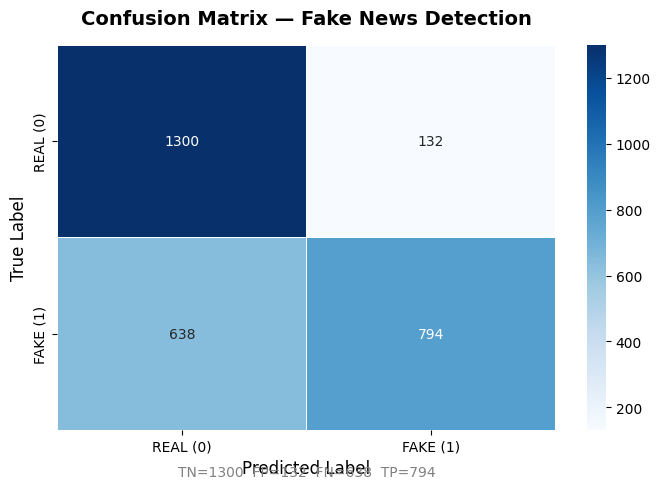

  TN=1300  FP=132  FN=638  TP=794
✅ Confusion matrix saved!


In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
class_names = ["REAL (0)", "FAKE (1)"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax)
ax.set_title("Confusion Matrix — Fake News Detection",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)

tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.12, f"TN={tn}  FP={fp}  FN={fn}  TP={tp}",
        ha="center", transform=ax.transAxes, fontsize=10, color="gray")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print("✅ Confusion matrix saved!")

## 📋 Section 19: Classification Report

In [18]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true, y_pred,
    target_names=["REAL", "FAKE"],
    digits=4,
    zero_division=0
)

print("=" * 55)
print("          CLASSIFICATION REPORT")
print("=" * 55)
print(report)
print("=" * 55)

          CLASSIFICATION REPORT
              precision    recall  f1-score   support

        REAL     0.6708    0.9078    0.7715      1432
        FAKE     0.8575    0.5545    0.6735      1432

    accuracy                         0.7311      2864
   macro avg     0.7641    0.7311    0.7225      2864
weighted avg     0.7641    0.7311    0.7225      2864



## 📈 Section 20: Dataset Visualization

Visualizing dataset composition, label distribution, and model performance.

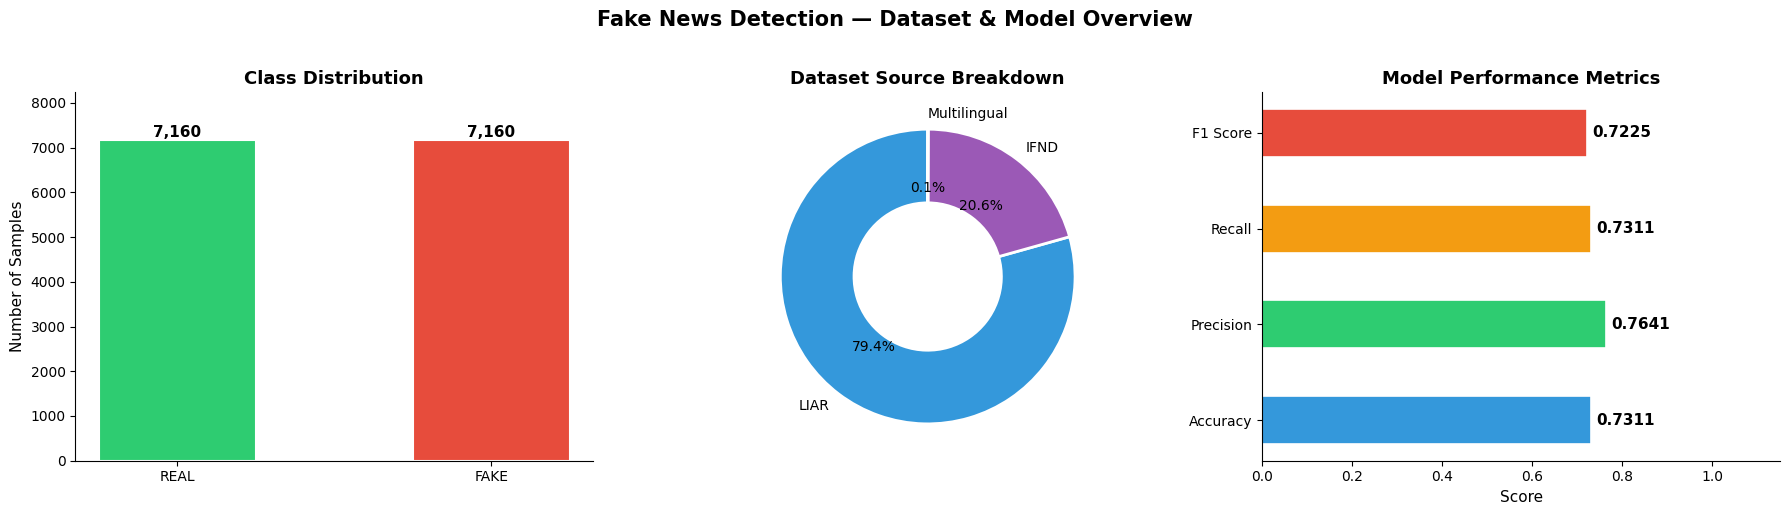

✅ Visualization saved!


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Fake News Detection — Dataset & Model Overview",
             fontsize=15, fontweight="bold", y=1.02)

# ── Plot 1: Class Distribution ─────────────────────────────────
colors = ["#2ecc71", "#e74c3c"]
labels_count = [(balanced_df["label"]==0).sum(),
                (balanced_df["label"]==1).sum()]
bars = axes[0].bar(["REAL", "FAKE"], labels_count, color=colors,
                   edgecolor="white", linewidth=1.5, width=0.5)
axes[0].set_title("Class Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Samples", fontsize=11)
for bar, cnt in zip(bars, labels_count):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(labels_count)*0.01,
                 f"{cnt:,}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylim(0, max(labels_count) * 1.15)
axes[0].spines[["top","right"]].set_visible(False)

# ── Plot 2: Source Breakdown ────────────────────────────────────
src_counts = balanced_df["source"].value_counts()
wedge_props = dict(width=0.5, edgecolor="white", linewidth=2)
palette = ["#3498db", "#9b59b6", "#f39c12"][:len(src_counts)]
axes[1].pie(src_counts.values, labels=src_counts.index,
            autopct="%1.1f%%", colors=palette,
            wedgeprops=wedge_props, startangle=90)
axes[1].set_title("Dataset Source Breakdown", fontsize=13, fontweight="bold")

# ── Plot 3: Model Performance ───────────────────────────────────
metrics       = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1}
metric_colors = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c"]
m_bars = axes[2].barh(list(metrics.keys()), list(metrics.values()),
                      color=metric_colors, edgecolor="white",
                      linewidth=1.2, height=0.5)
axes[2].set_xlim(0, 1.15)
axes[2].set_title("Model Performance Metrics", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Score", fontsize=11)
for bar, val in zip(m_bars, metrics.values()):
    axes[2].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=11, fontweight="bold")
axes[2].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("dataset_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualization saved!")

## 🔍 Section 21: Explainable AI (SHAP)

Using **SHAP** to explain which words most influenced the model's fake news prediction.

The `shap.Explainer` uses a partition-based approach with the XLM-RoBERTa tokenizer.
If SHAP text rendering is unavailable, a word-perturbation fallback is used instead.

⚙️  Setting up SHAP explainer (small sample for speed)...

📊 SHAP Word Attribution (FAKE probability):


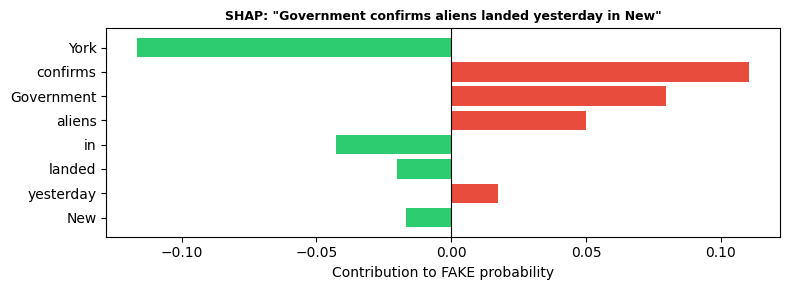

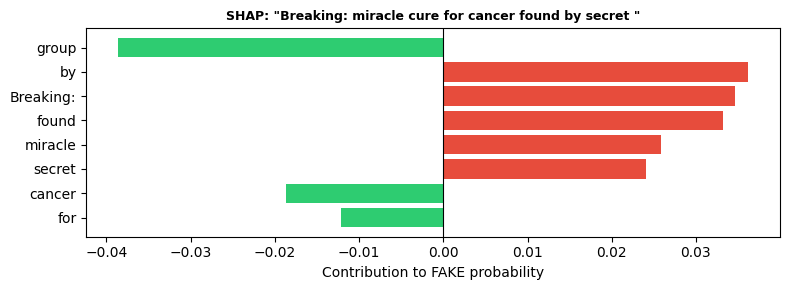

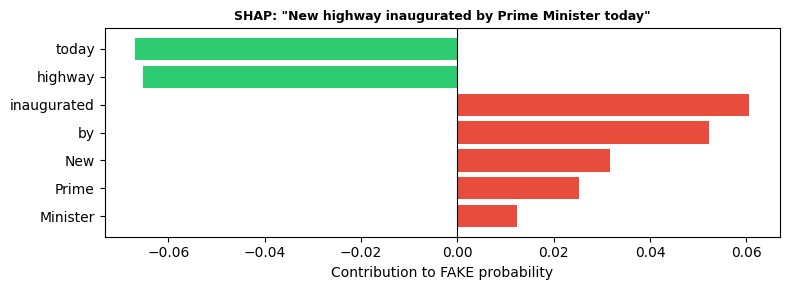


✅ SHAP analysis complete!


In [20]:
import shap
import torch

print("⚙️  Setting up SHAP explainer (small sample for speed)...")

model.eval()

def shap_predict(texts):
    """Wrapper: returns FAKE class probability for a list of texts."""
    encodings = tokenizer(
        list(texts),
        truncation=True,
        padding="max_length",
        max_length=128,
        return_tensors="pt"
    )
    encodings = {k: v.to(device) for k, v in encodings.items()}
    with torch.no_grad():
        outputs = model(**encodings)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs[:, 1].cpu().numpy()

shap_sample_texts = [
    "Government confirms aliens landed yesterday in New York",
    "India launches PSLV-C55 successfully into orbit",
    "Breaking: miracle cure for cancer found by secret group",
    "New highway inaugurated by Prime Minister today"
]

shap_success = False
try:
    masker = shap.maskers.Text(tokenizer=r"\W+")
    explainer = shap.Explainer(shap_predict, masker)
    # max_evals reduced to 100 for speed on T4
    shap_values = explainer(shap_sample_texts, max_evals=100, batch_size=4)
    print("\n📊 SHAP Word Attribution (FAKE probability):")
    # Use matplotlib bar chart instead of shap.plots.text for reliable Colab rendering
    for i, text in enumerate(shap_sample_texts):
        vals = shap_values[i].values
        words = shap_sample_texts[i].split()
        if len(vals) == len(words):
            sorted_pairs = sorted(zip(words, vals), key=lambda x: abs(x[1]), reverse=True)[:8]
            w, v = zip(*sorted_pairs)
            fig, ax = plt.subplots(figsize=(8, 3))
            ax.barh(w, v, color=["#e74c3c" if x > 0 else "#2ecc71" for x in v])
            ax.set_title(f'SHAP: "{text[:50]}"', fontsize=9, fontweight='bold')
            ax.set_xlabel("Contribution to FAKE probability")
            ax.axvline(0, color="black", lw=0.8)
            ax.invert_yaxis()
            plt.tight_layout()
            plt.show()
    shap_success = True
    print("\n✅ SHAP analysis complete!")
except Exception as e:
    print(f"ℹ️  SHAP Explainer unavailable: {e}")

if not shap_success:
    print("\n📊 Fallback: Word Perturbation Attribution")

    def word_importance(text):
        words = text.split()
        base_score = float(shap_predict([text])[0])
        importances = {}
        for i, word in enumerate(words):
            masked = words[:i] + ["_"] + words[i+1:]
            masked_score = float(shap_predict([" ".join(masked)])[0])
            importances[word] = base_score - masked_score
        return importances

    for text in shap_sample_texts[:2]:
        word_imp = word_importance(text)
        sorted_imp = sorted(word_imp.items(), key=lambda x: abs(x[1]), reverse=True)[:10]
        words_s, scores_s = zip(*sorted_imp)
        fig, ax = plt.subplots(figsize=(9, 3))
        ax.barh(words_s, scores_s,
                color=["#e74c3c" if s > 0 else "#2ecc71" for s in scores_s])
        ax.set_title(f'Attribution: "{text[:55]}"',
                     fontsize=10, fontweight="bold")
        ax.set_xlabel("Impact on FAKE probability")
        ax.axvline(0, color="black", lw=0.8)
        ax.invert_yaxis()
        plt.tight_layout()
        plt.savefig("shap_word_attribution.png", dpi=150)
        plt.show()
    print("✅ Word attribution complete!")

## 📊 Section 22: Confidence Score Visualization

Visualizing model confidence (softmax probability) for sample predictions.

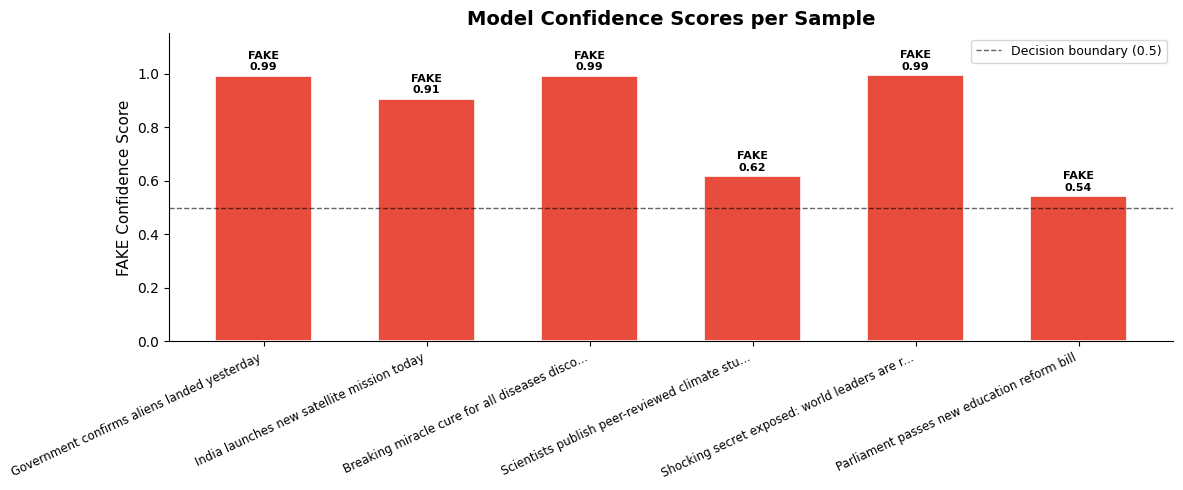


  Results:
  TEXT                                            PRED   CONFIDENCE
  -----------------------------------------------------------------
  Government confirms aliens landed yesterday     FAKE   0.9919
  India launches new satellite mission today      FAKE   0.9056
  Breaking miracle cure for all diseases disco... FAKE   0.9918
  Scientists publish peer-reviewed climate stu... FAKE   0.6180
  Shocking secret exposed: world leaders are r... FAKE   0.9945
  Parliament passes new education reform bill     FAKE   0.5425


In [21]:
model.eval()
sample_texts_conf = [
    "Government confirms aliens landed yesterday",
    "India launches new satellite mission today",
    "Breaking miracle cure for all diseases discovered secretly",
    "Scientists publish peer-reviewed climate study",
    "Shocking secret exposed: world leaders are reptiles",
    "Parliament passes new education reform bill"
]

conf_results = []
for text in sample_texts_conf:
    enc = tokenizer(text, return_tensors="pt", truncation=True,
                    padding="max_length", max_length=128)
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
        probs  = torch.nn.functional.softmax(logits, dim=-1)[0]
    fake_conf = probs[1].item()
    real_conf = probs[0].item()
    pred_label = "FAKE" if fake_conf > 0.5 else "REAL"
    conf_results.append({
        "text"      : (text[:44] + "...") if len(text) > 44 else text,
        "prediction": pred_label,
        "fake_conf" : fake_conf,
        "real_conf" : real_conf
    })

fig, ax = plt.subplots(figsize=(12, 5))
x = list(range(len(conf_results)))
bar_colors = ["#e74c3c" if r["prediction"]=="FAKE" else "#2ecc71"
              for r in conf_results]

bars = ax.bar(x, [r["fake_conf"] for r in conf_results],
              color=bar_colors, edgecolor="white", linewidth=1.2, width=0.6)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1,
           alpha=0.6, label="Decision boundary (0.5)")
ax.set_xticks(x)
ax.set_xticklabels([r["text"] for r in conf_results],
                   rotation=25, ha="right", fontsize=8.5)
ax.set_ylabel("FAKE Confidence Score", fontsize=11)
ax.set_title("Model Confidence Scores per Sample", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9)

for bar, r in zip(bars, conf_results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{r['prediction']}\n{r['fake_conf']:.2f}",
            ha="center", fontsize=8, fontweight="bold")

ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("confidence_scores.png", dpi=150)
plt.show()

print("\n  Results:")
print(f"  {'TEXT':<47} {'PRED':<6} CONFIDENCE")
print("  " + "-" * 65)
for r in conf_results:
    print(f"  {r['text']:<47} {r['prediction']:<6} {r['fake_conf']:.4f}")

## 🏅 Section 23: Credibility Scoring System

A composite credibility engine combining:
- 🤖 Model confidence (primary signal)
- ⚠️ Suspicious keyword detection  
- 📐 Linguistic pattern analysis

> **Score 0–100**: Higher = More credible (Real News)

In [22]:
import re

SUSPICIOUS_KEYWORDS = [
    "miracle", "shocking", "exposed", "secret", "breaking",
    "conspiracy", "cover-up", "deep state", "they don't want you",
    "banned", "hidden truth", "wake up", "mainstream media lies",
    "cure", "hoax", "illuminati", "chemtrail",
    "reptilian", "microchip", "mind control", "satanic"
]

CREDIBLE_PATTERNS = [
    r"according to \w+",
    r"study (?:shows|finds|suggests)",
    r"researchers? (?:found|discovered|published)",
    r"government (?:confirms|announces|releases)",
    r"official (?:statement|report|data)",
    r"\d{4}\s*(?:study|report|survey)",
]

SUSPICIOUS_PATTERNS = [
    r"!{2,}|\?{2,}",
    r"shocking truth",
    r"you won'?t believe",
    r"they (?:don'?t|won'?t) tell you",
]

def compute_credibility_score(text, fake_confidence):
    score = 100.0
    # Model confidence penalty (max -50)
    score -= fake_confidence * 50
    # Suspicious keywords (max -30)
    text_lower = text.lower()
    kw_hits = [kw for kw in SUSPICIOUS_KEYWORDS if kw in text_lower]
    score -= min(len(kw_hits) * 6, 30)
    # Credible patterns bonus (max +15)
    cred_hits = sum(1 for p in CREDIBLE_PATTERNS if re.search(p, text_lower))
    score += min(cred_hits * 5, 15)
    # Suspicious patterns penalty (max -10)
    susp_hits = sum(1 for p in SUSPICIOUS_PATTERNS if re.search(p, text_lower))
    score -= min(susp_hits * 5, 10)
    # Excessive caps penalty
    caps_ratio = sum(1 for c in text if c.isupper()) / max(len(text), 1)
    if caps_ratio > 0.3:
        score -= 5
    return max(0, min(100, round(score))), kw_hits

def get_credibility_label(score):
    if score >= 75: return "🟢 HIGH CREDIBILITY"
    elif score >= 50: return "🟡 MODERATE CREDIBILITY"
    elif score >= 25: return "🟠 LOW CREDIBILITY"
    else:            return "🔴 VERY LOW CREDIBILITY"

print("✅ Credibility scoring system initialized!")
print(f"  Suspicious keywords : {len(SUSPICIOUS_KEYWORDS)}")
print(f"  Credible patterns   : {len(CREDIBLE_PATTERNS)}")

✅ Credibility scoring system initialized!
  Suspicious keywords : 21
  Credible patterns   : 6


## 🧠 Section 24: Fake News Reasoning Analysis

Highlighting suspicious phrases and generating human-readable explanations.

In [23]:
def analyze_fake_news_reasoning(text, prediction, fake_conf, credibility_score, kw_hits):
    reasons = []
    if fake_conf > 0.85:
        reasons.append("🔴 Very high model confidence in FAKE classification")
    elif fake_conf > 0.65:
        reasons.append("🟠 Elevated model confidence in FAKE classification")

    if kw_hits:
        reasons.append(f"⚠️  Suspicious keywords: {', '.join(kw_hits[:5])}")

    text_lower = text.lower()
    if re.search(r"!{2,}|\?{2,}", text):
        reasons.append("⚠️  Excessive punctuation (!! or ??) detected")
    if sum(c.isupper() for c in text) / max(len(text), 1) > 0.3:
        reasons.append("⚠️  Excessive capitalization detected")
    if re.search(r"you won'?t believe|shocking|exposed|secret", text_lower):
        reasons.append("⚠️  Clickbait-style language detected")
    if re.search(r"\b(?:miracle|cure|banned|hidden)\b", text_lower):
        reasons.append("⚠️  Pseudoscientific or conspiracy-adjacent terms found")
    if re.search(r"according to|researchers?|study (?:shows|finds)", text_lower):
        reasons.append("✅ Text references sources or studies")
    if re.search(r"official|government|parliament|minister", text_lower):
        reasons.append("✅ Mentions official institutions")

    if not reasons:
        reasons.append("🤖 Model flagged based on learned patterns" if prediction=="FAKE"
                       else "✅ No suspicious signals detected")
    return reasons

demo_texts = [
    "Breaking miracle cure for cancer exposed — they don't want you to know!",
    "India launches PSLV-C55 carrying Singapore satellites into orbit",
    "Shocking secret: Government putting microchips in vaccines!!",
    "Parliament passes new education bill with bipartisan support"
]

print("=" * 65)
print("         FAKE NEWS REASONING ANALYSIS")
print("=" * 65)

model.eval()
for text in demo_texts:
    enc = tokenizer(text, return_tensors="pt", truncation=True,
                    padding="max_length", max_length=128)
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
        probs  = torch.nn.functional.softmax(logits, dim=-1)[0]
    fake_conf  = probs[1].item()
    prediction = "FAKE" if fake_conf > 0.5 else "REAL"
    cred_score, kw_hits = compute_credibility_score(text, fake_conf)
    reasons = analyze_fake_news_reasoning(text, prediction, fake_conf, cred_score, kw_hits)

    print(f"\n📰 {text}")
    print(f"   Prediction        : {'❌' if prediction=='FAKE' else '✅'} {prediction}")
    print(f"   Fake Confidence   : {fake_conf:.4f} ({fake_conf*100:.1f}%)")
    print(f"   Credibility Score : {cred_score}/100  {get_credibility_label(cred_score)}")
    print("   Reasoning:")
    for r in reasons:
        print(f"     → {r}")
    print("   " + "-"*60)

         FAKE NEWS REASONING ANALYSIS

📰 Breaking miracle cure for cancer exposed — they don't want you to know!
   Prediction        : ❌ FAKE
   Fake Confidence   : 0.9971 (99.7%)
   Credibility Score : 20/100  🔴 VERY LOW CREDIBILITY
   Reasoning:
     → 🔴 Very high model confidence in FAKE classification
     → ⚠️  Suspicious keywords: miracle, exposed, breaking, they don't want you, cure
     → ⚠️  Clickbait-style language detected
     → ⚠️  Pseudoscientific or conspiracy-adjacent terms found
   ------------------------------------------------------------

📰 India launches PSLV-C55 carrying Singapore satellites into orbit
   Prediction        : ❌ FAKE
   Fake Confidence   : 0.9927 (99.3%)
   Credibility Score : 50/100  🟡 MODERATE CREDIBILITY
   Reasoning:
     → 🔴 Very high model confidence in FAKE classification
   ------------------------------------------------------------

📰 Shocking secret: Government putting microchips in vaccines!!
   Prediction        : ❌ FAKE
   Fake Confi

## ⚙️ Section 25: Prediction Function

The unified `predict_news(text)` function — one call returns everything.

In [24]:
def predict_news(text):
    """
    Comprehensive fake news prediction.
    Returns: prediction, confidence, credibility score, reasoning.
    """
    model.eval()
    enc = tokenizer(text, return_tensors="pt", truncation=True,
                    padding="max_length", max_length=128)
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
        probs  = torch.nn.functional.softmax(logits, dim=-1)[0]

    fake_conf  = probs[1].item()
    real_conf  = probs[0].item()
    prediction = "FAKE" if fake_conf > 0.5 else "REAL"
    cred_score, kw_hits = compute_credibility_score(text, fake_conf)
    cred_label = get_credibility_label(cred_score)
    reasons    = analyze_fake_news_reasoning(
        text, prediction, fake_conf, cred_score, kw_hits)

    return {
        "prediction"        : prediction,
        "fake_confidence"   : round(fake_conf, 4),
        "real_confidence"   : round(real_conf, 4),
        "credibility_score" : cred_score,
        "credibility_label" : cred_label,
        "suspicious_words"  : kw_hits,
        "reasoning"         : reasons
    }

def display_prediction(text):
    result = predict_news(text)
    emoji  = "❌" if result["prediction"] == "FAKE" else "✅"
    print("=" * 65)
    print(f"📰 {text}")
    print("=" * 65)
    print(f"  {emoji} Prediction         : {result['prediction']}")
    print(f"  📊 Fake Confidence    : {result['fake_confidence']} "
          f"({result['fake_confidence']*100:.1f}%)")
    print(f"  📊 Real Confidence    : {result['real_confidence']} "
          f"({result['real_confidence']*100:.1f}%)")
    print(f"  🏅 Credibility Score  : {result['credibility_score']}/100")
    print(f"  🏅 Credibility Label  : {result['credibility_label']}")
    if result["suspicious_words"]:
        print(f"  ⚠️  Suspicious Words   : {', '.join(result['suspicious_words'])}")
    print("  🧠 Reasoning:")
    for r in result["reasoning"]:
        print(f"       → {r}")
    print("=" * 65)

print("✅ predict_news() and display_prediction() are ready!")

✅ predict_news() and display_prediction() are ready!


## 🧪 Section 26: Example Predictions

Testing the complete system on a range of example headlines.

In [25]:
examples = [
    "Government confirms aliens landed yesterday in New York City",
    "India launches new satellite mission today — ISRO achieves orbit",
    "Breaking miracle cure for cancer found — Big Pharma doesn't want you to know!!",
    "Scientists publish peer-reviewed study on climate change impacts",
    "Shocking secret exposed: World leaders are secretly reptilian beings",
    "Parliament approves national budget with infrastructure focus",
    "You won't believe what they've been hiding in your drinking water",
    "Reserve Bank of India holds interest rates steady at policy meeting"
]

print("🧪 EXAMPLE PREDICTIONS")
print("=" * 65)

for text in examples:
    display_prediction(text)
    print()

🧪 EXAMPLE PREDICTIONS
📰 Government confirms aliens landed yesterday in New York City
  ❌ Prediction         : FAKE
  📊 Fake Confidence    : 0.991 (99.1%)
  📊 Real Confidence    : 0.009 (0.9%)
  🏅 Credibility Score  : 55/100
  🏅 Credibility Label  : 🟡 MODERATE CREDIBILITY
  🧠 Reasoning:
       → 🔴 Very high model confidence in FAKE classification
       → ✅ Mentions official institutions

📰 India launches new satellite mission today — ISRO achieves orbit
  ❌ Prediction         : FAKE
  📊 Fake Confidence    : 0.9887 (98.9%)
  📊 Real Confidence    : 0.0113 (1.1%)
  🏅 Credibility Score  : 51/100
  🏅 Credibility Label  : 🟡 MODERATE CREDIBILITY
  🧠 Reasoning:
       → 🔴 Very high model confidence in FAKE classification

📰 Breaking miracle cure for cancer found — Big Pharma doesn't want you to know!!
  ❌ Prediction         : FAKE
  📊 Fake Confidence    : 0.9985 (99.9%)
  📊 Real Confidence    : 0.0015 (0.1%)
  🏅 Credibility Score  : 27/100
  🏅 Credibility Label  : 🟠 LOW CREDIBILITY
  ⚠️  Suspi

## 💾 Section 27: Model Saving

Saving the trained model and tokenizer. The model archive download is **optional** —
uncomment the last block if you want to download the full ~1.1 GB zip.

In [31]:
import os, shutil

SAVE_DIR = "./fake_news_model"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"💾 Saving model and tokenizer to: {SAVE_DIR}/")
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print("\n📁 Saved files:")
total_size = 0
for f in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, f)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1e6
        total_size += size
        print(f"   📄 {f:<40} ({size:.2f} MB)")
print(f"\n   Total size: {total_size:.1f} MB")

print("\n" + "=" * 65)
print("  ✅  TRAINING & EVALUATION COMPLETE!")
print("=" * 65)
print(f"  Model       : XLM-RoBERTa Base")
print(f"  Accuracy    : {acc*100:.2f}%")
print(f"  F1 Score    : {f1:.4f}")
print(f"  Saved to    : {SAVE_DIR}/")
print("=" * 65)
print("\n🎉 Advanced Multilingual Fake News Detection System ready!")

# ── Optional: Download model archive (~1.1 GB) ──────────────────
# Uncomment the block below ONLY if you want to download the model.
# This may take several minutes depending on your connection speed.

import shutil
from google.colab import files

print("\n⏳ Zipping model archive (this may take a few minutes)...")
shutil.make_archive("fake_news_model", "zip", SAVE_DIR)

print("⬇️ Downloading...")
files.download("fake_news_model.zip")

💾 Saving model and tokenizer to: ./fake_news_model/


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


📁 Saved files:
   📄 config.json                              (0.00 MB)
   📄 model.safetensors                        (1112.20 MB)
   📄 tokenizer.json                           (16.78 MB)
   📄 tokenizer_config.json                    (0.00 MB)
   📄 training_args.bin                        (0.01 MB)

   Total size: 1129.0 MB

  ✅  TRAINING & EVALUATION COMPLETE!
  Model       : XLM-RoBERTa Base
  Accuracy    : 73.11%
  F1 Score    : 0.7225
  Saved to    : ./fake_news_model/

🎉 Advanced Multilingual Fake News Detection System ready!

⏳ Zipping model archive (this may take a few minutes)...
⬇️ Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>